# OSM data processing notebook

**Description**

This notebook is used for processing OSM data and create both public urban green spaces (PUGS) binary mask and PUGS Signed-Distance Transform (SDT) raster to feed as an input to deep learning model in later step.

Main steps of OSM data processing:
1. Import data 
2. Process data (doing the spatial join)
3. Classify Land use/Land cover(LULC) spaces to be public or non-public area
4. Clean the data
5. Create PUGS binary mask and SDT raster

**Input file(s)**

8 files
- LULC related to green spaces from landuse tag (`green_landuse_area_dresden.geojson`)
- LULC related to green spaces from leisure tag (`green_leisure_area_dresden.geojson`)
- LULC related to green spaces from natural tag (`green_natural_area_dresden.geojson`)
- LULC related to green spaces from campsite tag (`green_campsite_area_dresden.geojson`)
- Location of POI from amenity tag (`poi_amenity_dresden.geojson`)
- Location of POI from leisure tag (`poi_leisure_dresden.geojson`)
- Location of POI from viewpoint tag (`poi_viewpoint_dresden.geojson`)
- Footpath network (`footpath_network_edges.geojson`)

**Output file(s)**

4 files
- PUGS derived from OSM data (`public_green_spaces_dresden.geojson`)
- PUGS derived from OSM data in form of binary mask (`public_green_spaces_dresden.geotiff`)
- SDT of PUGS derived from OSM data (`sdt_public_green_spaces_dresden.geotiff`)
- The distribution of number of classified PUGS based on different classifcation method (`osm_pugs_classification_method.png`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

# 1. Import libraries and load config

It can take up to 5-6 mins to complete this section.

In [27]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [28]:
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.colors as mcolors
import yaml
from pugs_detection.utils import (
    print_basic_info,
)
from pugs_detection.osm import (
    load_osm_data,
    print_classification_report,
    calculate_poi_number,
    calculate_footpath_length,
    classification_with_smaller_area,
)

from pugs_detection.ground_truth import (
    add_ndvi_to_polygons,
    print_non_green_space_info,
)
from pugs_detection.raster import (
    create_binary_mask,
    create_sdt_raster,
)

from pugs_detection.plots import plot_classification_osm

In [29]:
# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [30]:
# set crs param
crs = config["data"]["crs"]

# 2. Import data

## LULC space from landuse key

In [31]:
file_path = config["paths"]["green_landuse_path"]
green_landuse_area = load_osm_data(file_path, crs)

In [32]:
print_basic_info(green_landuse_area)

Number of rows: 12620
Number of columns: 126


,element,id,landuse,name,denomination,religion,wikidata,check_date:opening_hours,opening_hours,website,...,substance,utility,was:man_made,name:en,level,material,type,name:hsb,source:outline,geometry
0,node,593500300,meadow,Fasanenwiese,None,None,None,NaT,None,None,...,None,None,None,None,None,None,None,None,None,POINT (409534.707 5668038.509)
1,node,593504848,forest,Fuchsbruch,None,None,None,NaT,None,None,...,None,None,None,None,None,None,None,None,None,POINT (409318.056 5667413.545)
2,relation,6128,forest,Dresdner Heide,None,None,Q8905,NaT,None,None,...,None,None,None,None,None,None,multipolygon,Drježdźanska hola,None,"MULTIPOLYGON (((422682.225 5662327.517, 422778..."


In [33]:
# Select only some columns
green_landuse_area = green_landuse_area[
    [
        "element",
        "id",
        "landuse",
        "name",
        "barrier",
        "note",
        "opening_hours",
        "access",
        "description",
        "leisure",
        "tourism",
        "surface",
        "landcover",
        "amenity",
        "natural",
        "type",
        "geometry",
    ]
]

In [34]:
green_landuse_area["area"] = green_landuse_area["geometry"].area

## LULC space from leisure key

In [35]:
file_path = config["paths"]["green_leisure_path"]
green_leisure_area = load_osm_data(file_path, crs)

In [36]:
print_basic_info(green_leisure_area)

Number of rows: 3963
Number of columns: 149


,element,id,created_by,leisure,wheelchair,access,name,opening_hours,operator,sport,...,name:de,pitch:net,pitch:net:material,pitch:net:overhang,construction,operator:short,animal_training,type,name:fr,geometry
0,node,255545201,Potlatch 0.8a,playground,no,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (409940.451 5652983.729)
1,node,262693384,JOSM,playground,limited,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (414361.811 5663180.907)
2,node,266593887,None,playground,None,yes,Würzburger Straße - Park,Mo-Su 08:00-22:00,Landeshauptstadt Dresden,None,...,None,None,None,None,None,None,None,None,None,POINT (409905.579 5653957.552)


In [37]:
# Select only some columns
green_leisure_area = green_leisure_area[
    [
        "element",
        "id",
        "access",
        "leisure",
        "name",
        "opening_hours",
        "indoor",
        "operator",
        "description",
        "playground",
        "note",
        "surface",
        "fee",
        "barrier",
        "landuse",
        "natural",
        "charge",
        "landcover",
        "fence_type",
        "garden:type",
        "wall",
        "type",
        "geometry",
    ]
]

In [38]:
green_leisure_area["area"] = green_leisure_area["geometry"].area

## LULC space from nature key

In [39]:
file_path = config["paths"]["green_natural_path"]
green_natural_area = load_osm_data(file_path, crs)

In [40]:
print_basic_info(green_natural_area)

Number of rows: 4610
Number of columns: 80


,element,id,natural,wetland,name,source:name,old_name,source,boundary,denotation,...,comment,area,check_date,area:highway,fee,species:wikipedia,type,nature,protected_area,geometry
0,node,2583496631,wetland,swamp,None,None,None,None,None,None,...,None,None,NaT,None,None,None,None,None,None,POINT (418793.941 5666708.208)
1,node,9042465204,wood,None,Kirsten Buschgen,Meilenblatt Sachsen 1783,None,None,None,None,...,None,None,NaT,None,None,None,None,None,None,POINT (427333.114 5654745.676)
2,node,9124027180,wood,None,Der Strang,None,Strange Holtz,Meilenblätter Sachsen 1783 Blatt 264,None,None,...,None,None,NaT,None,None,None,None,None,None,POINT (426484.877 5665108.539)


In [41]:
green_natural_area = green_natural_area[
    [
        "element",
        "id",
        "natural",
        "name",
        "note",
        "leisure",
        "description",
        "barrier",
        "landuse",
        "landcover",
        "access",
        "fee",
        "type",
        "geometry",
    ]
]

In [42]:
green_natural_area["area"] = green_natural_area["geometry"].area

## LULC space from tourism key

In [43]:
file_path = config["paths"]["green_campsite_path"]
green_campsite_area = load_osm_data(file_path, crs)

In [44]:
print_basic_info(green_campsite_area)

Number of rows: 199
Number of columns: 115


,element,id,created_by,tourism,access,addr:city,addr:country,addr:housenumber,addr:postcode,addr:street,...,motor_vehicle,beds,group_only,guest_house,rooms,attraction,capacity:disabled,seasonal,socket:cee_blue,geometry
0,node,257564076,JOSM,picnic_site,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (411597.918 5665030.941)
1,node,257564078,JOSM,picnic_site,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (411626.748 5664796.911)
2,node,257922815,JOSM,picnic_site,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (411564.728 5665084.269)


In [45]:
green_campsite_area["area"] = green_campsite_area["geometry"].area

## POI/Amenity from amenity key

In [46]:
file_path = config["paths"]["poi_amenity_path"]
poi_amenity = load_osm_data(file_path, crs)

In [47]:
print_basic_info(poi_amenity)

Number of rows: 10248
Number of columns: 83


,element,id,amenity,backrest,description,direction,material,seats,wikimedia_commons,created_by,...,deposit_ring,support,seats:separated,outdoor_seating,leisure,barrier,height,area,man_made,geometry
0,node,251567329,bench,yes,Bank am Zickzack-Weg,100,wood,3,File:Bank am Zickzackweg.jpg,None,...,None,None,None,None,None,None,None,None,None,POINT (403728.926 5649371.357)
1,node,255298026,bench,yes,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (415787.203 5655716.144)
2,node,255925960,waste_basket,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (409010.616 5654975)


## POI/Amenity from leisure key

In [48]:
file_path = config["paths"]["poi_leisure_path"]
poi_leisure = load_osm_data(file_path, crs)

In [49]:
print_basic_info(poi_leisure)

Number of rows: 1611
Number of columns: 84


,element,id,created_by,leisure,wheelchair,access,name,opening_hours,operator,sport,...,playground:springy,fixme,start_date,contact:email,contact:mobile,contact:website,addr:suburb,construction,type,geometry
0,node,255545201,Potlatch 0.8a,playground,no,None,None,None,None,None,...,None,None,NaT,None,None,None,None,None,None,POINT (409940.451 5652983.729)
1,node,262693384,JOSM,playground,limited,None,None,None,None,None,...,None,None,NaT,None,None,None,None,None,None,POINT (414361.811 5663180.907)
2,node,266593887,None,playground,None,yes,Würzburger Straße - Park,Mo-Su 08:00-22:00,Landeshauptstadt Dresden,None,...,None,None,NaT,None,None,None,None,None,None,POINT (409905.579 5653957.552)


## POI/Amenity from tourism key

In [50]:
file_path = config["paths"]["poi_viewpoint_path"]
poi_viewpoint = load_osm_data(file_path, crs)

In [51]:
print_basic_info(poi_viewpoint)

Number of rows: 216
Number of columns: 75


,element,id,highway,toilets:wheelchair,tourism,wheelchair,name,name:de,noexit,description,...,source,tower:construction,charge,comment,old_name,loc_name,subject:wikipedia,building:levels,name:en,geometry
0,node,67366424,turning_circle,yes,viewpoint,yes,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (403904.735 5663529.148)
1,node,71744963,None,None,viewpoint,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (406659.489 5667933.973)
2,node,248567811,None,None,viewpoint,no,Am Zwingergraben,Am Zwingergraben,yes,None,...,None,None,None,None,None,None,None,None,None,POINT (411130.285 5656571.446)


## Walking path

In [52]:
file_path = config["paths"]["footpath_network_path"]
footpath_network_edges = load_osm_data(file_path, crs)

Skipping field highway: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field service: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field tunnel: unsupported OGR type: 5


In [53]:
print_basic_info(footpath_network_edges)

Number of rows: 313296
Number of columns: 12


,u,v,key,osmid,oneway,reversed,length,access,junction,est_width,area,geometry
0,442734,1839778041,0,1338016415,False,True,72.940783,None,None,None,None,"LINESTRING (411407.486 5652433.485, 411472.711..."
1,442734,442736,0,92,False,False,169.821618,None,None,None,None,"LINESTRING (411407.486 5652433.485, 411445.258..."
2,442734,9907191675,0,105,False,False,55.779311,None,None,None,None,"LINESTRING (411407.486 5652433.485, 411369.586..."


### Filter only footpath that access is public

In [54]:
footpath_network_edges = footpath_network_edges[
    (footpath_network_edges["access"] == "permissive")
    | (footpath_network_edges["access"] == "yes")
    | (footpath_network_edges["access"] == "public")
    | (footpath_network_edges["access"] == "foot")
]

# 3. Process data

---

Define custom color map for visualization

In [55]:
# Create custom color map
colors = mcolors.ListedColormap(
    ["#ff4d4d", "#4dff4d"]
)  # Red for private, Green for public

---

In [56]:
all_lulc_space_gdf = pd.concat(
    [green_landuse_area, green_leisure_area, green_natural_area, green_campsite_area],
    ignore_index=True,
)

In [57]:
all_lulc_space_gdf = all_lulc_space_gdf[
    [
        "element",
        "id",
        "landuse",
        "name",
        "barrier",
        "note",
        "opening_hours",
        "access",
        "description",
        "leisure",
        "tourism",
        "surface",
        "landcover",
        "indoor",
        "natural",
        "type",
        "geometry",
        "area",
        "operator",
        "playground",
        "fee",
        "charge",
        "fence_type",
        "garden:type",
    ]
]

In [58]:
print_basic_info(all_lulc_space_gdf)

Number of rows: 21392
Number of columns: 24


,element,id,landuse,name,barrier,note,opening_hours,access,description,leisure,...,natural,type,geometry,area,operator,playground,fee,charge,fence_type,garden:type
0,node,593500300,meadow,Fasanenwiese,None,None,None,None,None,None,...,None,None,POINT (409534.707 5668038.509),0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
1,node,593504848,forest,Fuchsbruch,None,None,None,None,None,None,...,None,None,POINT (409318.056 5667413.545),0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
2,relation,6128,forest,Dresdner Heide,None,None,None,None,None,None,...,None,multipolygon,"MULTIPOLYGON (((422682.225 5662327.517, 422778...",5.293124e+07,NaN,NaN,NaN,NaN,NaN,NaN


## Spatial join

**Note:** This step won't remove the polygon that is inside the bigger polygon. Small polygon's attributes will also be concatenated with Bigger polygon.

In [59]:
joined_lulc_space = all_lulc_space_gdf.sjoin(
    all_lulc_space_gdf, how="left", predicate="contains"
)

In [60]:
print_basic_info(joined_lulc_space)

Number of rows: 23497
Number of columns: 48


,element_left,id_left,landuse_left,name_left,barrier_left,note_left,opening_hours_left,access_left,description_left,leisure_left,...,indoor_right,natural_right,type_right,area_right,operator_right,playground_right,fee_right,charge_right,fence_type_right,garden:type_right
0,node,593500300,meadow,Fasanenwiese,None,None,None,None,None,None,...,NaN,None,None,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,node,593504848,forest,Fuchsbruch,None,None,None,None,None,None,...,NaN,None,None,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,relation,6128,forest,Dresdner Heide,None,None,None,None,None,None,...,NaN,None,None,26701.181844,NaN,NaN,NaN,NaN,NaN,NaN


**Note:** Some green spaces also contain the small area that has non-green/non-vegetation surface. But then again, if the area of small polygon is less than 100 sq.m., it is filtered out in te later step.

# 4. Classify LULC spaces by using tag

## 4.1. Use fee and charge tag to classify private area

In [61]:
joined_lulc_space.loc[
    (joined_lulc_space["fee_left"] == "yes")
    | (~joined_lulc_space["charge_left"].isna()),
    ["is_public", "classification_step"]
] = ["no", "tag"]

## 4.2. Use access tag to classify
- Access = yes/permissive -> public
- Access = no/private/customers/restricted -> private

In [62]:
joined_lulc_space.loc[
    (
        (joined_lulc_space["access_left"] == "yes")
        | (joined_lulc_space["access_left"] == "permissive")
    )
    & (joined_lulc_space["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["yes", "tag"]

In [63]:
joined_lulc_space.loc[
    (joined_lulc_space["access_left"] != "yes")
    & (joined_lulc_space["access_left"] != "permissive")
    & (~joined_lulc_space["access_left"].isna())
    & (joined_lulc_space["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["no", "tag"]

## 4.3. Use tag to classify non-public area
- tourism=zoo
- leisure=golf_course
- garden:type=residential/private
- landuse=vineyard or landuse=meadow (mostly represent pasture area)

In [64]:
joined_lulc_space["garden:type_left"].unique()

array([nan, None, 'botanical', 'community', 'residential', 'show_garden',
       'flowerbed', 'private', 'landscaping'], dtype=object)

In [65]:
joined_lulc_space.loc[
    (
        (joined_lulc_space["tourism_left"] == "zoo")
        | (joined_lulc_space["leisure_left"] == "golf_course")
        | (joined_lulc_space["garden:type_left"] == "residential")
        | (joined_lulc_space["garden:type_left"] == "private")
        | (joined_lulc_space["landuse_left"] == "vineyard")
        | (joined_lulc_space["landuse_left"] == "meadow")
    )
    & (joined_lulc_space["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["no", "tag"]

## 4.4. Use leisure=park tag to classify public area

In [66]:
joined_lulc_space.loc[
    (joined_lulc_space["leisure_left"] == "park")
    & (joined_lulc_space["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["yes", "tag"]

## 4.5. Use another leisure and landuse tag to classify public/non-public

If leisure=nature_reserve or landuse=cemetery, classify as public

In [67]:
joined_lulc_space.loc[
    (
        (joined_lulc_space["leisure_left"] == "nature_reserve")
        | (joined_lulc_space["landuse_left"] == "cemetery")
    )
    & (joined_lulc_space["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["yes", "tag"]

If landuse=allotments, classify as non-public

In [68]:
joined_lulc_space.loc[
    (joined_lulc_space["landuse_left"] == "allotments")
    & (joined_lulc_space["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["no", "tag"]

## 4.6. Use barrier tag to classify non-public area

In [69]:
joined_lulc_space.loc[
    (~joined_lulc_space["barrier_left"].isna())
    & (joined_lulc_space["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["no", "tag"]

In [70]:
# Doesn't want to make false report on the percentage of the green space (area)
show_pc = joined_lulc_space.drop_duplicates(subset=["id_left"])

In [71]:
print_classification_report(show_pc)

total LULC spaces: 21326
total labeled LULC spaces: 6568
total public LULC spaces: 1369
total non-public LULC spaces: 5199
--------------------
total LULC spaces (area): 384202593.27397025
percentage of labeled LULC spaces (area): 26.87%
percentage of public LULC spaces (area): 5.58%
percentage of non-public LULC spaces (area): 21.29%


# 5. Create additional information to classify public/non-public area

- Presence/number of benches, playgrounds, waste baskets, picnic tables, and viewpoints for each area
- Presence of walking path

In [72]:
joined_lulc_space_with_poi = (
    joined_lulc_space.pipe(calculate_poi_number, poi_amenity, "amenity")
    .pipe(calculate_poi_number, poi_leisure, "leisure")
    .pipe(calculate_poi_number, poi_viewpoint, "tourism")
    .pipe(calculate_footpath_length, footpath_network_edges)
)

In [73]:
joined_lulc_space_with_poi.head()

,element_left,id_left,landuse_left,name_left,barrier_left,note_left,opening_hours_left,access_left,description_left,leisure_left,...,fence_type_right,garden:type_right,is_public,classification_step,bench,waste_basket,picnic_table,playground,viewpoint,length
0,node,593500300,meadow,Fasanenwiese,None,None,None,None,None,None,...,NaN,NaN,no,tag,0.0,0.0,0.0,0.0,0.0,0.000000
1,node,593504848,forest,Fuchsbruch,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.000000
2,relation,6128,forest,Dresdner Heide,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,140.0,3.0,12.0,6.0,3.0,4864.166807
3,relation,6128,forest,Dresdner Heide,None,None,None,None,None,None,...,None,NaN,NaN,NaN,140.0,3.0,12.0,6.0,3.0,4864.166807
4,relation,6128,forest,Dresdner Heide,None,None,None,None,None,None,...,None,None,NaN,NaN,140.0,3.0,12.0,6.0,3.0,4864.166807


# 6. Classify LULC spaces based on additional indicators

Refer to mapping guide of European Urban Atlas

## If the area is forest and there is trace of recreational activity, classify the area as public

In [74]:
joined_lulc_space_with_poi.loc[
    (
        (joined_lulc_space_with_poi["bench"] > 0)
        | (joined_lulc_space_with_poi["waste_basket"] > 0)
        | (joined_lulc_space_with_poi["playground"] > 0)
        | (joined_lulc_space_with_poi["picnic_table"] > 0)
        | (joined_lulc_space_with_poi["length"] > 0)
    )
    & (
        (joined_lulc_space_with_poi["landuse_left"] == "forest")
        | (joined_lulc_space_with_poi["natural_left"] == "wood")
    )
    & (joined_lulc_space_with_poi["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["yes", "additional poi"]

In [75]:
# Doesn't want to make false report on the percentage of the green space (area)
show_pc = joined_lulc_space_with_poi.drop_duplicates(subset=["id_left"])

In [76]:
print_classification_report(show_pc)

total LULC spaces: 21326
total labeled LULC spaces: 6796
total public LULC spaces: 1597
total non-public LULC spaces: 5199
--------------------
total LULC spaces (area): 384202593.27397025
percentage of labeled LULC spaces (area): 80.58%
percentage of public LULC spaces (area): 59.3%
percentage of non-public LULC spaces (area): 21.29%


## If there is the viewpoint in area, classify as public

In [77]:
joined_lulc_space_with_poi.loc[
    (joined_lulc_space_with_poi["viewpoint"] > 0)
    & (joined_lulc_space_with_poi["is_public"].isna()),
    ["is_public", "classification_step"]
] = ["yes", "additional poi"]

In [78]:
# Doesn't want to make false report on the percentage of the green space (area)
show_pc = joined_lulc_space_with_poi.drop_duplicates(subset=["id_left"])

In [79]:
print_classification_report(show_pc)

total LULC spaces: 21326
total labeled LULC spaces: 6835
total public LULC spaces: 1636
total non-public LULC spaces: 5199
--------------------
total LULC spaces (area): 384202593.27397025
percentage of labeled LULC spaces (area): 80.95%
percentage of public LULC spaces (area): 59.66%
percentage of non-public LULC spaces (area): 21.29%


# 7. Classify LULC spaces by using small polygon inside larger polygon

In [80]:
unlabeled_lulc_space = joined_lulc_space_with_poi[
    joined_lulc_space_with_poi["is_public"].isna()
]

To classify the accessibility of green spaces (larger polygon), I use the area of small polygon inside them to classify.
- If total public area inside polygon are more than non-public, that polygon is classifies as public
- If total non-public area + unclassified area inside polygon are more than public, that polygon is classifies as non-public

**Note:** Some polygon might also contain the node (playground, pitch, garden, etc.). I also assign the area for the node to make it be able to aggregate with small polygon's area. So, below code is or finding the average percentage of playground, pitch, garden, etc. in the green space based on the classified green spaces data.

In [81]:
leisure_node_element_list = (
    joined_lulc_space_with_poi[
        (joined_lulc_space_with_poi["element_right"] == "node")
        & (
            joined_lulc_space_with_poi["id_left"]
            != joined_lulc_space_with_poi["id_right"]
        )
    ]["leisure_right"]
    .unique()
    .tolist()
)
landuse_node_element_list = (
    joined_lulc_space_with_poi[
        (joined_lulc_space_with_poi["element_right"] == "node")
        & (
            joined_lulc_space_with_poi["id_left"]
            != joined_lulc_space_with_poi["id_right"]
        )
    ]["landuse_right"]
    .unique()
    .tolist()
)
print("leisure tag of node element in polygon:", leisure_node_element_list)
print("landuse tag of node element in polygon:", landuse_node_element_list)

leisure tag of node element in polygon: [None, 'pitch', 'playground', 'picnic_table', 'garden']
landuse tag of node element in polygon: [None, 'meadow', 'forest']


The rules to classify polygon:
- Public >= 50% -> public
- Non-public+unclassified >= 50% -> non-public

In [82]:
final_classified_lulc_space = classification_with_smaller_area(
    joined_lulc_space_with_poi
)

leisure tag of node element in polygon: [None, 'pitch', 'playground', 'picnic_table', 'garden']
landuse tag of node element in polygon: [None, 'meadow', 'forest']
estimated average percentage of each leisure/landuse: {'forest': 7, 'playground': 6, 'pitch': 6, 'meadow': 6, 'garden': 2}
final estimated average percentage area: {'forest': 7, 'playground': 6, 'pitch': 6, 'meadow': 6, 'garden': 2, None: 1, 'picnic_table': 1}
larger polygon id: 18622415    small polygon id: [1354952533]
larger polygon id: 165505041    small polygon id: [163418178]
larger polygon id: 190708040    small polygon id: [190708057]
larger polygon id: 238260545    small polygon id: [2463155102, 3518017063, 1097604854, 345110108, 345110103]
larger polygon id: 329102185    small polygon id: [307673236, 1219826678, 3724867245, 329102191, 28079891]
larger polygon id: 1354952533    small polygon id: [18622415]
larger polygon id: 39362138    small polygon id: [413292359, 413292374]
larger polygon id: 232803037    small po

In [83]:
# doesn't want to make false report on the percentage of the green space (area)
show_pc = final_classified_lulc_space.drop_duplicates(subset=["id_left"])

In [84]:
print_classification_report(show_pc)

total LULC spaces: 21326
total labeled LULC spaces: 6846
total public LULC spaces: 1637
total non-public LULC spaces: 5209
--------------------
total LULC spaces (area): 384202593.27397025
percentage of labeled LULC spaces (area): 80.97%
percentage of public LULC spaces (area): 59.66%
percentage of non-public LULC spaces (area): 21.3%


# 8. Clean data

## Filter area that is < 100 m2 out

In [85]:
filtered_lulc_space = final_classified_lulc_space[
    final_classified_lulc_space["area_left"] > 100
].copy()

In [86]:
show_pc = filtered_lulc_space.drop_duplicates(subset=["id_left"])

In [87]:
print_classification_report(show_pc)

total LULC spaces: 17566
total labeled LULC spaces: 5993
total public LULC spaces: 1306
total non-public LULC spaces: 4687
--------------------
total LULC spaces (area): 384076243.83560723
percentage of labeled LULC spaces (area): 80.99%
percentage of public LULC spaces (area): 59.68%
percentage of non-public LULC spaces (area): 21.31%


## Remove indoor space out

In [88]:
print("indoor tag:", filtered_lulc_space["indoor_left"].unique())
print(
    "indoor tag (polygon/node inside bigger pollygon):",
    filtered_lulc_space["indoor_right"].unique(),
)

indoor tag: [nan None]
indoor tag (polygon/node inside bigger pollygon): [nan None 'yes' 'no']


In [89]:
filtered_lulc_space = filtered_lulc_space[filtered_lulc_space["indoor_left"] != "yes"]

In [90]:
print_classification_report(show_pc)

total LULC spaces: 17566
total labeled LULC spaces: 5993
total public LULC spaces: 1306
total non-public LULC spaces: 4687
--------------------
total LULC spaces (area): 384076243.83560723
percentage of labeled LULC spaces (area): 80.99%
percentage of public LULC spaces (area): 59.68%
percentage of non-public LULC spaces (area): 21.31%


## Remove polygon that is not green space/surface isn't grass out (if surface value is specified) and keep it in another df

Note: Only non-green space inside the green space polygon are kept

In [91]:
small_polygon_id = (
    filtered_lulc_space[
        filtered_lulc_space["id_left"] != filtered_lulc_space["id_right"]
    ]["id_right"]
    .unique()
    .tolist()
)
all_polygon_id = filtered_lulc_space["id_left"].unique()

In [92]:
print("surface:", filtered_lulc_space["surface_left"].unique(), "\n")
print("leisure:", filtered_lulc_space["leisure_left"].unique(), "\n")
print("natural:", filtered_lulc_space["natural_left"].unique())

surface: [None 'grass' 'gravel' 'tartan' 'artificial_turf' 'clay' 'sand' 'asphalt'
 'ground' 'fine_gravel' 'compacted' 'dirt' 'rubber' 'concrete'
 'paving_stones' 'sett' 'unpaved' 'pebblestone' 'wood' 'woodchips'
 'decoturf' 'textile' 'dirt/sand' 'acrylic' 'paved' 'textile_chips' nan] 

leisure: [None 'park' 'water_park' 'playground' 'garden' 'pitch' 'nature_reserve'
 'golf_course' 'dog_park'] 

natural: [None 'scrub' 'grassland' 'wetland' 'wood' 'water' 'plant' 'heath']


In [93]:
non_green_surface = filtered_lulc_space[
    (filtered_lulc_space["id_left"].isin(small_polygon_id))
    & (
        (
            (filtered_lulc_space["surface_left"] != "grass")
            & (~filtered_lulc_space["surface_left"].isna())
        )
        | (filtered_lulc_space["leisure_left"] == "water_park")
        | (filtered_lulc_space["natural_left"] == "water")
    )
]

In [94]:
non_green_surface = non_green_surface.drop_duplicates(subset=["id_left"])

In [95]:
print("total non-green areas:", non_green_surface.shape[0])

total non-green areas: 115


In [96]:
print(
    "average area of small polygon that is non-green surface:",
    non_green_surface["area_left"].mean(),
)

average area of small polygon that is non-green surface: 712.5293632702957


In [97]:
final_green_spaces = filtered_lulc_space[
    ~(
        (
            (filtered_lulc_space["surface_left"] != "grass")
            & (~filtered_lulc_space["surface_left"].isna())
        )
        | (filtered_lulc_space["leisure_left"] == "water_park")
        | (filtered_lulc_space["natural_left"] == "water")
    )
]

In [98]:
# Doesn't want to make false report on the percentage of the green space (area)
show_pc = final_green_spaces.drop_duplicates(subset=["id_left"])

In [99]:
print_classification_report(show_pc)

total LULC spaces: 17076
total labeled LULC spaces: 5882
total public LULC spaces: 1271
total non-public LULC spaces: 4611
--------------------
total LULC spaces (area): 383391986.6659582
percentage of labeled LULC spaces (area): 81.09%
percentage of public LULC spaces (area): 59.78%
percentage of non-public LULC spaces (area): 21.31%


# 9. Overlay

1. Overlay between green spaces and non-green spaces
2. Overlay between public and non-public green spaces

## Overlay between green spaces and non-green spaces

In [100]:
final_green_spaces = final_green_spaces.drop_duplicates(subset=["id_left"])

In [101]:
final_green_spaces = gpd.overlay(
    final_green_spaces, non_green_surface, how="difference"
)

In [102]:
print_classification_report(final_green_spaces)

total LULC spaces: 17076
total labeled LULC spaces: 5882
total public LULC spaces: 1271
total non-public LULC spaces: 4611
--------------------
total LULC spaces (area): 383391986.6659582
percentage of labeled LULC spaces (area): 81.09%
percentage of public LULC spaces (area): 59.78%
percentage of non-public LULC spaces (area): 21.31%


In [103]:
print(
    "average area of unclassified green spaces:",
    final_green_spaces[final_green_spaces["is_public"].isna()]["area_left"].mean(),
)

average area of unclassified green spaces: 6475.412314076151


## Overlay between public and non-public green spaces

In [104]:
public_green_space = final_green_spaces[final_green_spaces["is_public"] == "yes"]
non_public_green_space = final_green_spaces[final_green_spaces["is_public"] == "no"]

In [105]:
pugs_within_nonpugs_list = (
    public_green_space.sjoin(
        non_public_green_space, how="inner", predicate="within", rsuffix="_right_2"
    )["id_left_left"]
    .unique()
    .tolist()
)

In [106]:
# After taking the difference (the area that mark as pugs inside non-pugs will be gone)
# This can be argue -> to ensure the minimum public green space
public_green_space[
    public_green_space["id_left"].isin(pugs_within_nonpugs_list)
].explore()

In [107]:
clean_public_green_space = public_green_space.overlay(
    non_public_green_space, how="difference"
)

In [108]:
print_classification_report(clean_public_green_space)

total LULC spaces: 1254
total labeled LULC spaces: 1254
total public LULC spaces: 1254
total non-public LULC spaces: 0
--------------------
total LULC spaces (area): 229137443.09704256
percentage of labeled LULC spaces (area): 100.0%
percentage of public LULC spaces (area): 100.0%
percentage of non-public LULC spaces (area): 0.0%


In [109]:
# clean_public_green_space.explore()

#  10. Filter non-green space out from datasets

If the average NDVI of the area/polygon **<=** 0.3, consider it as non-green.

This threshold was selected because, mostly, values below 0.3 represent non-green or low vegetation areas. The selection was further supported by visual inspection of the imagery in the study area.

In [110]:
# Rosa 
# # Check the created mask against the original raster NDVI
sentinel2_raster_path = (
    "../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff"
)
green_osm_dataset_ndvi = add_ndvi_to_polygons(
    clean_public_green_space, raster_path=sentinel2_raster_path, ndvi_band_index=16
)

filtered_green_osm_dataset = green_osm_dataset_ndvi[
    green_osm_dataset_ndvi["ndvi_mean"] > 0.3
].copy()

In [111]:
print_non_green_space_info(green_osm_dataset_ndvi, threshold=0.3)
print_non_green_space_info(filtered_green_osm_dataset, threshold=0.3)

Area of polygons with NDVI <= 0.3:
Low NDVI value area: 34312.37 m² from 228227574.07 m² (0.02%)
Area of polygons with NDVI <= 0.3:
Low NDVI value area: 0.00 m² from 228192132.26 m² (0.00%)


In [112]:
green_osm_dataset_ndvi.shape[0], filtered_green_osm_dataset.shape[0]

(1254, 1205)

In [113]:
# there are some polygons that have no NDVI value, we need to check them
# most probaly they are outside the raster area, or they are too small to be captured by the raster
green_osm_dataset_ndvi[green_osm_dataset_ndvi.ndvi_mean.isna()]

,element_left,id_left,landuse_left,name_left,barrier_left,note_left,opening_hours_left,access_left,description_left,leisure_left,...,garden:type_right,is_public,classification_step,bench,waste_basket,picnic_table,playground,viewpoint,length,ndvi_mean
267,way,684747071,forest,None,None,None,None,None,None,None,...,NaN,yes,additional poi,4.0,0.0,0.0,0.0,0.0,0.0,NaN
491,way,42282349,None,None,None,None,None,yes,None,playground,...,None,yes,tag,3.0,3.0,0.0,1.0,0.0,0.0,NaN
731,way,235622510,None,None,None,None,None,None,None,park,...,None,yes,tag,0.0,0.0,0.0,0.0,0.0,0.0,NaN
982,way,684851613,None,Schlosspark,None,None,None,None,None,park,...,None,yes,tag,4.0,0.0,0.0,0.0,0.0,0.0,NaN
983,way,684851615,None,Chinesischer Garten,None,None,None,None,None,park,...,None,yes,tag,0.0,0.0,0.0,0.0,0.0,0.0,NaN
985,way,684851617,None,Holländischer Garten,None,None,None,None,None,park,...,None,yes,tag,4.0,0.0,0.0,0.0,0.0,0.0,NaN
990,way,720164756,None,Otto-Wittich-Platz,None,None,None,None,Benannt nach dem Heimatforscher und Ortschroni...,park,...,None,yes,tag,2.0,0.0,0.0,0.0,0.0,0.0,NaN
995,way,736273639,None,None,None,None,None,None,None,park,...,None,yes,tag,5.0,2.0,0.0,0.0,0.0,0.0,NaN
997,way,743680953,None,Eisenbahn-Spielplatz,None,None,None,yes,None,playground,...,None,yes,tag,0.0,0.0,0.0,1.0,0.0,0.0,NaN
1090,way,1044439376,None,None,None,None,None,yes,None,playground,...,None,yes,tag,1.0,0.0,0.0,1.0,0.0,0.0,NaN


In [114]:
green_osm_dataset_ndvi[green_osm_dataset_ndvi.geometry.area < 100]

,element_left,id_left,landuse_left,name_left,barrier_left,note_left,opening_hours_left,access_left,description_left,leisure_left,...,garden:type_right,is_public,classification_step,bench,waste_basket,picnic_table,playground,viewpoint,length,ndvi_mean
267,way,684747071,forest,None,None,None,None,None,None,None,...,NaN,yes,additional poi,4.0,0.0,0.0,0.0,0.0,0.0,NaN
982,way,684851613,None,Schlosspark,None,None,None,None,None,park,...,None,yes,tag,4.0,0.0,0.0,0.0,0.0,0.0,NaN
983,way,684851615,None,Chinesischer Garten,None,None,None,None,None,park,...,None,yes,tag,0.0,0.0,0.0,0.0,0.0,0.0,NaN
985,way,684851617,None,Holländischer Garten,None,None,None,None,None,park,...,None,yes,tag,4.0,0.0,0.0,0.0,0.0,0.0,NaN


In [115]:
green_osm_dataset_ndvi[green_osm_dataset_ndvi['ndvi_mean'] >= 0.3].shape

(1211, 57)

In [116]:
# compare the filtered dataset with the original dataset

bins = [0, 4000, 30000, 100000, 800000, green_osm_dataset_ndvi.geometry.area.max()]
labels = ["<= 0.4", "(0.4, 3]", "(3, 10]", "(10, 80]", "> 80"]
green_osm_dataset_ndvi["area_group"] = pd.cut(green_osm_dataset_ndvi.geometry.area, bins=bins, labels=labels, include_lowest=True)
filtered_green_osm_dataset["area_group"] = pd.cut(filtered_green_osm_dataset.geometry.area, bins=bins, labels=labels, include_lowest=True)
print("Original dataset area group value counts:")
print(green_osm_dataset_ndvi["area_group"].value_counts())
print("Filtered dataset area group value counts:")
print(filtered_green_osm_dataset["area_group"].value_counts())

Original dataset area group value counts:
area_group
<= 0.4      743
(0.4, 3]    324
(10, 80]     80
(3, 10]      79
> 80         28
Name: count, dtype: int64
Filtered dataset area group value counts:
area_group
<= 0.4      696
(0.4, 3]    322
(10, 80]     80
(3, 10]      79
> 80         28
Name: count, dtype: int64


# 10. Save classified green spaces and filtered green spaces

In [117]:
output_path = config["paths"]["pugs_vector_path"]
output_path_nofiltered = config["paths"]["pugs_vector_nofiltered_path"]
if not os.path.exists(os.path.dirname(output_path)):
    os.makedirs(os.path.dirname(output_path))

clean_public_green_space.to_file(
    output_path_nofiltered, driver="GeoJSON"
)
# save in output path the filtered one
filtered_green_osm_dataset.to_file(
    output_path, driver="GeoJSON"
)



# 11. Create binary mask

In [118]:
# Open the GeoTIFF file
raster_template_file_path = config["paths"]["raw_sentinel_path"]
with rasterio.open(raster_template_file_path) as dataset:
    # Get the width and height of the image
    width = dataset.width
    height = dataset.height

    # Print the width and height
    print(f"Width: {width} pixels")
    print(f"Height: {height} pixels")

Width: 2747 pixels
Height: 2301 pixels


In [119]:
# use the filtered version as default
create_binary_mask(
    filtered_green_osm_dataset,
    config["paths"]["pugs_mask_path"],
    raster_template_file_path,
)
create_binary_mask(
    clean_public_green_space,
    config["paths"]["pugs_nofiltered_mask_path"],
    raster_template_file_path,
)

Rasterization complete.
Rasterization complete.


# 12. Create Signed-distance transform

In [120]:
# use the filtered version as default
create_sdt_raster(
    filtered_green_osm_dataset,
    config["paths"]["pugs_sdt_path"],
    raster_template_file_path,
)

# create STD raster for nofiltered green space
create_sdt_raster(
    clean_public_green_space,
    config["paths"]["pugs_nofiltered_sdt_path"],
    raster_template_file_path,
)

Signed distance transform complete.
Signed distance transform complete.


---

# Additional: Plot classification method stats

../s42/reports/figures/others/osm_pugs_classification_method.png


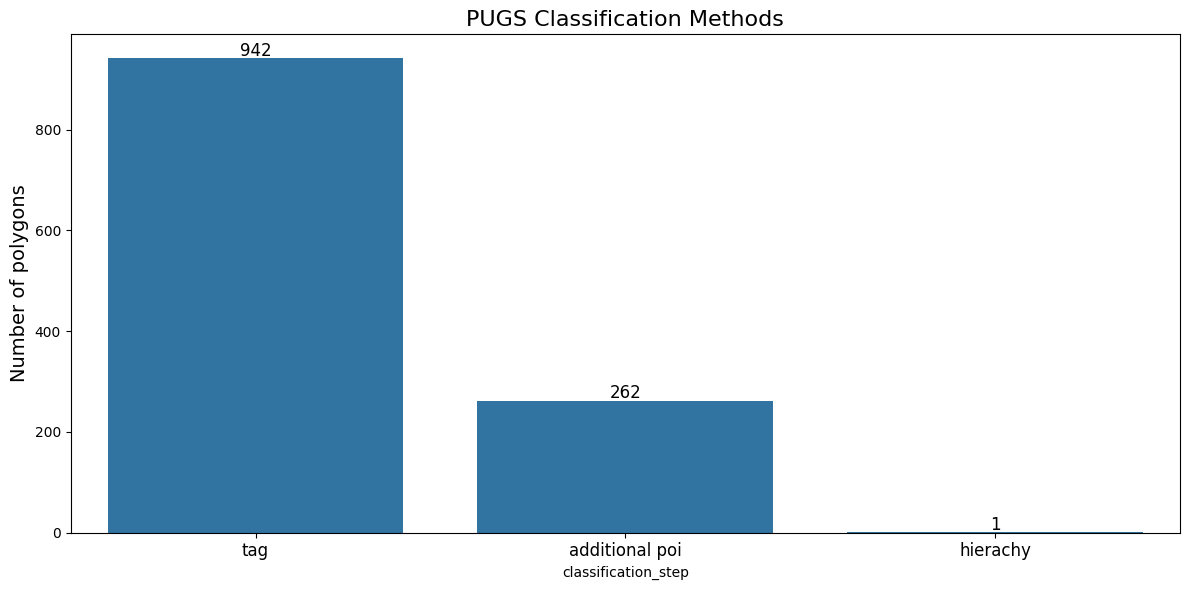

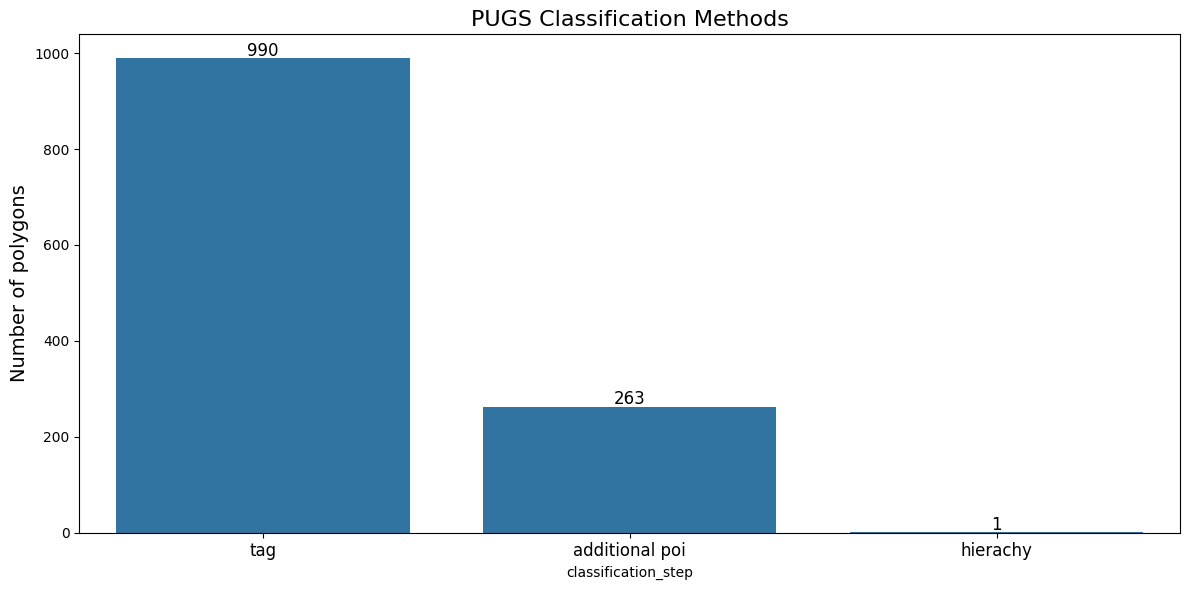

In [121]:
osm_classification_path = config["paths"]["osm_classification_path"].format(seed=config["general"]["seed"])
if not os.path.exists(os.path.dirname(osm_classification_path)):
    os.makedirs(os.path.dirname(osm_classification_path))
print(osm_classification_path)

plot_classification_osm(filtered_green_osm_dataset, osm_classification_path)
plot_classification_osm(clean_public_green_space, osm_classification_path.replace(".png", "_nofiltered.png"))